# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Define paths
zip_path = "/content/drive/MyDrive/Dataset_PNG.zip"  # Change this if needed
extract_path = "/content/Dataset_PNG"  # Folder where dataset will be extracted

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
os.listdir(extract_path)  # Should show "png" folder inside

['sketches_png']

In [ ]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['moon', 'spoon', 'scissors', 'pickup truck', 'santa claus', 'feather', 'panda', 'basket', 'apple', 'screwdriver', 'mouse (animal)', 'piano', 'teapot', 'head', 'tomato', 'tooth', 'windmill', 'lighter', 'shark', 'baseball bat', 'wheelbarrow', 'bridge', 'crane (machine)', 'loudspeaker', 'tire', 'mermaid', 'leaf', 'car (sedan)', 'cat', 'snowboard', 'bus', 'comb', 'airplane', 'keyboard', 'dolphin', 'boomerang', 'parrot', 'syringe', 'dog', 'grapes', 'computer monitor', 'snail', 'cloud', 'stapler', 'elephant', 'lobster', 'lion', 'canoe', 'pipe (for smoking)', 'fish', 'submarine', 'tiger', 'seagull', 'bookshelf', 'parachute', 'sword', 'hourglass', 'ear', 'telephone', 'sponge bob', 'ant', 'blimp', 'teacup', 'sailboat', 'swan', 'helicopter', 'fork', 'palm tree', 'wine-bottle', 'trombone', 'butterfly', 'train', 'pig', 'suitcase', 'alarm clock', 'mug', 'skyscraper', 'space shuttle', 'motorbike', 'rainbow', 'key', 'snake', 'candle', 'radio', 'flower with stem', 'trumpet', 'hedgehog', 'beer-mug', '

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 18.1 MB/s eta 0:00:00


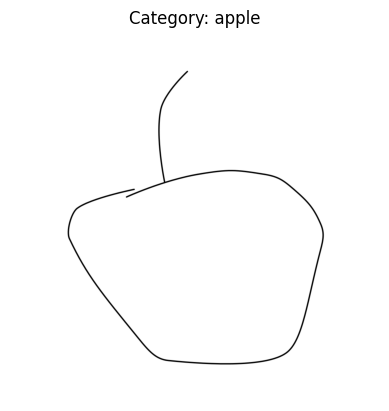

In [ ]:
!pip install opencv-python
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [ ]:
!pip install numpy scikit-learn tensorflow
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import img_to_array

# Parameters
img_size = 64  # Resize images to 64x64

X = []
y = []

for category in categories:
    folder = os.path.join(dataset_path, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (img_size, img_size))
        img = img_to_array(img)
        X.append(img)
        y.append(category)

X = np.array(X, dtype="float32") / 255.0  # Normalize
X = X.reshape(-1, img_size, img_size, 1)  # For CNN

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 594.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import tensorflow as tf
from skimage.color import gray2rgb
from skimage.transform import resize

# Convert grayscale to RGB
X_rgb = np.array([gray2rgb(img.squeeze()) for img in X])
X_resized = np.array([resize(img, (96, 96), anti_aliasing=True) for img in X_rgb])  # Resize for MobileNetV2

# Split
X_train, X_val, y_train, y_val = train_test_split(X_resized, y_categorical, test_size=0.2, random_state=42)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow(X_train, y_train, batch_size=64)
val_gen = datagen.flow(X_val, y_val, batch_size=64)

# Load MobileNetV2 base
base_model = MobileNetV2(include_top=False, input_shape=(96, 96, 3), weights='imagenet')
base_model.trainable = False  # Freeze base

# Add custom head
inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(y_categorical.shape[1], activation='softmax')(x)
model = Model(inputs, outputs)

# Compile and train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 252s 990ms/step - accuracy: 0.0500 - loss: 5.1870 - val_accuracy: 0.1528 - val_loss: 3.9804
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 236s 944ms/step - accuracy: 0.2030 - loss: 3.6319 - val_accuracy: 0.1900 - val_loss: 3.7548
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 238s 952ms/step - accuracy: 0.2632 - loss: 3.2511 - val_accuracy: 0.2122 - val_loss: 3.6271
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 234s 937ms/step - accuracy: 0.3085 - loss: 3.0063 - val_accuracy: 0.2155 - val_loss: 3.6026
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 233s 932ms/step - accuracy: 0.3398 - loss: 2.8074 - val_accuracy: 0.2255 - val_loss: 3.5189
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 229s 918ms/step - accuracy: 0.3664 - loss: 2.6719 - val_accuracy: 0.2380 - val_loss: 3.5165
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 234s 935ms/step - accuracy: 0.3947 - loss: 2.5565 - val_accuracy: 0.2460 - val_loss: 3.4387
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 233s 933ms/step - accuracy: 0.4084 -